# This code is use in Signal Processing Hackathon: Ultra Wide Band Pose Prediction

It will be incluse
- Create images (Absolute, transpose, DC noice)
- Train and predict image classification and detection (EVA02,YOLO-cls,YOLOv8)
- Ensemble

# 1. Create train and test image

In [8]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import scipy.fftpack as fft
from PIL import Image
import cv2
import sys
import shutil
import math
from tqdm import tqdm

In [9]:
df_annotations = pd.read_csv('/kaggle/input/ultra-wide-band-pose-prediction/annotations.csv')
df_classes = pd.read_csv('/kaggle/input/ultra-wide-band-pose-prediction/classes.csv')
df_sample_submission = pd.read_csv('/kaggle/input/ultra-wide-band-pose-prediction/sample_submission.csv')

In [10]:
def DC_Noise(range_time_data):
    range_time_data = range_time_data - np.mean(range_time_data, axis=0)
    return range_time_data

## Example of sample image that I generate

### 1.1 Absolute

(-0.5, 55.5, 2559.5, -0.5)

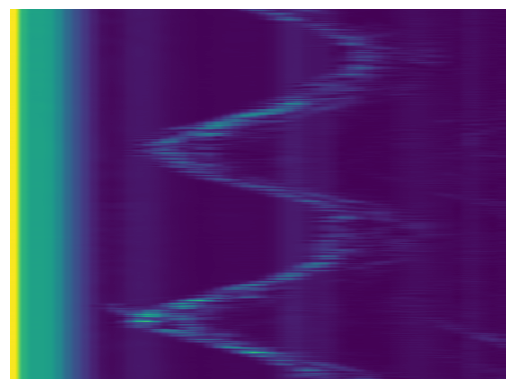

In [11]:
path = '/kaggle/input/ultra-wide-band-pose-prediction/train/train/' + str(df_annotations['id'][293]) + '.npy'
npy   = np.load(path) # load .npy file
ax1 = plt.subplot(1,1,1) # set subplot for plot image
im1 = ax1.imshow(np.abs(npy), aspect='auto') # use absolute in a + bi
plt.axis('off') # del axis
# plt.savefig('/kaggle/working/absolute.jpg') # save image

### 1.2 Absolute (transpose)

(-0.5, 2559.5, 55.5, -0.5)

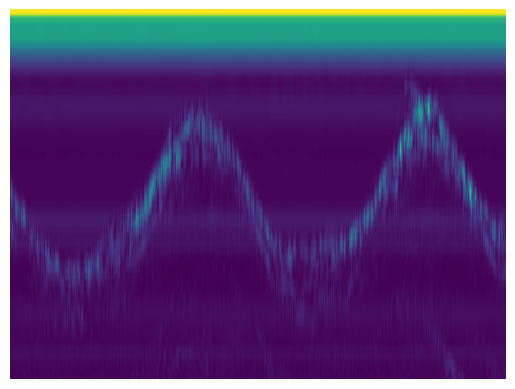

In [12]:
path = '/kaggle/input/ultra-wide-band-pose-prediction/train/train/' + str(df_annotations['id'][293]) + '.npy'
npy   = np.load(path) # load .npy file
npy = np.transpose(npy) # transpose data
ax1 = plt.subplot(1,1,1) # set subplot for plot image
im1 = ax1.imshow(np.abs(npy), aspect='auto') # use absolute in a + bi
plt.axis('off') # del axis
# plt.savefig('/kaggle/working/absolute.jpg') # save image

### 1.3 DC Noise cancellation

(-0.5, 2559.5, 55.5, -0.5)

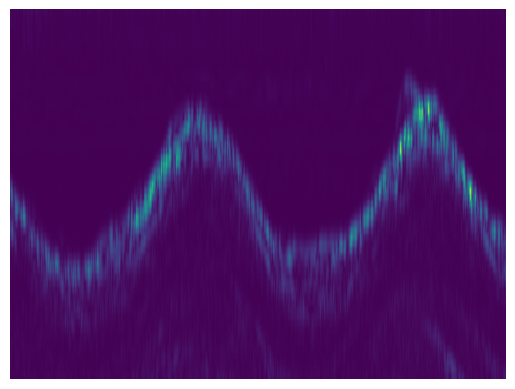

In [13]:
npy   = np.load(path)
npy = DC_Noise(npy) # Noice cancle
npy = np.transpose(npy) # transpose data
ax1 = plt.subplot(1,1,1)
im1 = ax1.imshow(np.abs(npy), aspect='auto') # use absolute in a + bi
plt.axis('off')
# plt.savefig('/kaggle/working/DC_noice.jpg')

### 1.4 Distance

(-0.5, 2559.5, 55.5, -0.5)

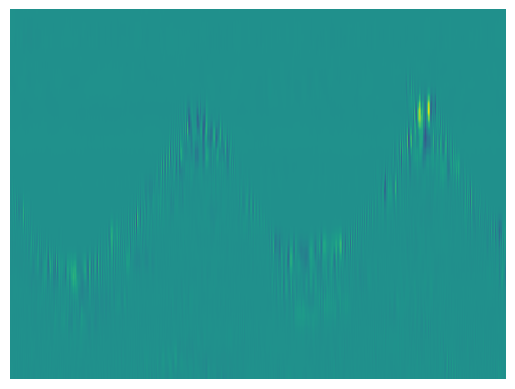

In [14]:
npy   = np.load(path)
npy = DC_Noise(npy) # Noice cancle
npy = np.transpose(npy) # transpose data
ax1 = plt.subplot(1,1,1)
im1 = ax1.imshow(npy.real, aspect='auto') # use a in a + bi
plt.axis('off')
# plt.savefig('/kaggle/working/distance.jpg')

### 1.5 Speed

(-0.5, 2559.5, 55.5, -0.5)

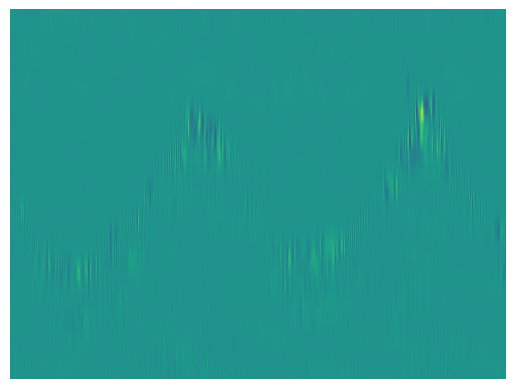

In [15]:
npy   = np.load(path)
npy = DC_Noise(npy) # Noice cancle
npy = np.transpose(npy)
ax1 = plt.subplot(1,1,1)
im1 = ax1.imshow(npy.imag, aspect='auto') # use b in a + bi   
plt.axis('off')
# plt.savefig('/kaggle/working/speed.jpg')

## I chose Absolute (transpose) abd DC Noise cancellation

## 1. Absolute (transpose) image generate code

In [16]:
os.mkdir('/kaggle/working/train_absolute')
os.mkdir('/kaggle/working/test_absolute')

  1%|          | 6/647 [00:02<04:36,  2.32it/s]


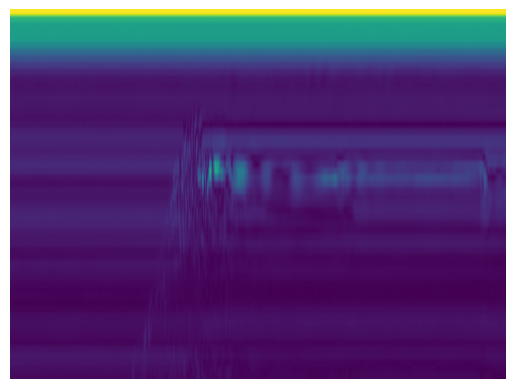

In [18]:
## Absolute (transpose) train image ##

for i in tqdm(range(len(df_annotations))):
    path = '/kaggle/input/ultra-wide-band-pose-prediction/train/train/' + str(df_annotations['id'][i]) + '.npy'
    npy   = np.load(path)
    npy = np.transpose(npy)
    ax1 = plt.subplot(1,1,1)
    im1 = ax1.imshow(np.abs(npy), aspect='auto')
    plt.axis('off')
    plt.savefig('/kaggle/working/train_absolute/' + str(i) + '.jpg')
    img = cv2.imread('/kaggle/working/train_absolute/' + str(i) + '.jpg')
    img = img[58:427,80:576]
    cv2.imwrite('/kaggle/working/train_absolute/' + str(i) + '.jpg', img) 
              
    if i > 5: 
        break

  4%|▎         | 6/164 [00:02<01:09,  2.26it/s]


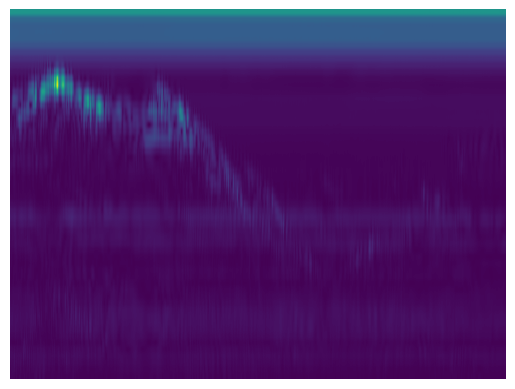

In [19]:
## Absolute (transpose) test image ##

for i in tqdm(range(len(df_sample_submission))):
    path = '/kaggle/input/ultra-wide-band-pose-prediction/test/test/' + str(df_sample_submission['id'][i]) + '.npy'
    npy   = np.load(path)
    npy = np.transpose(npy)
    ax1 = plt.subplot(1,1,1)
    im1 = ax1.imshow(np.abs(npy), aspect='auto')
    plt.axis('off')
    plt.savefig('/kaggle/working/test_absolute/' + str(df_sample_submission['id'][i]) + '.jpg')
    img = cv2.imread('/kaggle/working/test_absolute/' + str(df_sample_submission['id'][i]) + '.jpg')
    img = img[58:427,80:576]
    cv2.imwrite('/kaggle/working/test_absolute/' + str(df_sample_submission['id'][i]) + '.jpg', img) 
                  
    if i > 5: 
        break

## 2. DC Noise cancellation image generate code

In [20]:
os.mkdir('/kaggle/working/train_DC_Noise')
os.mkdir('/kaggle/working/test_DC_Noise')

  1%|          | 6/647 [00:02<04:29,  2.37it/s]


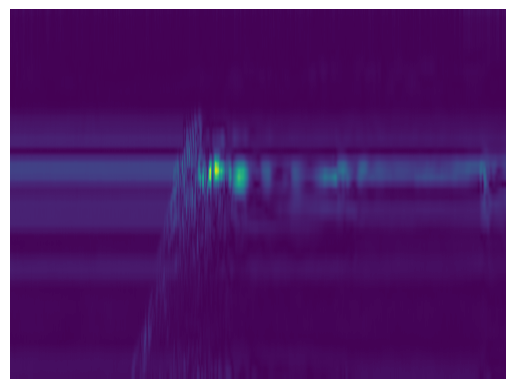

In [22]:
## DC Noise cancellation train image ##

for i in tqdm(range(len(df_annotations))):
    path = '/kaggle/input/ultra-wide-band-pose-prediction/train/train/' + str(df_annotations['id'][i]) + '.npy'
    npy   = np.load(path)
    npy = DC_Noise(npy) # Noice cancle
    npy = np.transpose(npy)
    ax1 = plt.subplot(1,1,1)
    im1 = ax1.imshow(np.abs(npy), aspect='auto')
    plt.axis('off')
    plt.savefig('/kaggle/working/train_DC_Noise/' + str(i) + '.jpg')
    img = cv2.imread('/kaggle/working/train_DC_Noise/' + str(i) + '.jpg')
    img = img[58:427,80:576]
    cv2.imwrite('/kaggle/working/train_DC_Noise/' + str(i) + '.jpg', img) 
                  
    if i > 5: 
        break

  4%|▎         | 6/164 [00:02<01:06,  2.37it/s]


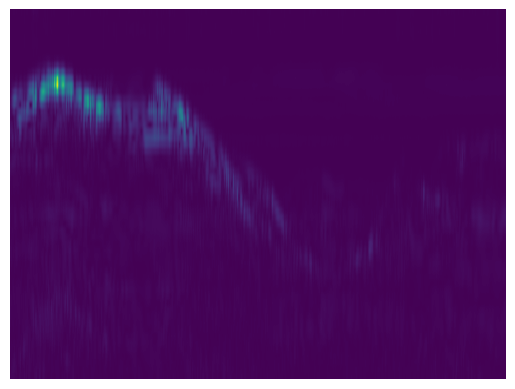

In [23]:
## DC Noise cancellation test image ##

for i in tqdm(range(len(df_sample_submission))):
    path = '/kaggle/input/ultra-wide-band-pose-prediction/test/test/' + str(df_sample_submission['id'][i]) + '.npy'
    npy   = np.load(path)
    npy = DC_Noise(npy) # Noice cancle
    npy = np.transpose(npy)
    ax1 = plt.subplot(1,1,1)
    im1 = ax1.imshow(np.abs(npy), aspect='auto')
    plt.axis('off')
    plt.savefig('/kaggle/working/test_DC_Noise/' + str(df_sample_submission['id'][i]) + '.jpg')
    img = cv2.imread('/kaggle/working/test_DC_Noise/' + str(df_sample_submission['id'][i]) + '.jpg')
    img = img[58:427,80:576]
    cv2.imwrite('/kaggle/working/test_DC_Noise/' + str(df_sample_submission['id'][i]) + '.jpg', img) 
                  
    if i > 5: 
        break

### Note: I already generate image so i am not gonna generate again in that notebook

# 2. After that i use those images in image classification (I train and predict on colab)

## 2.1 image classification (model = eva02_base_patch14_448.mim_in22k_ft_in22k_in1k)

### 2.1.1 Albumentations: Resize(448x448), GaussianBlur and RandomBrightnessContrast (Augment that move images might confuse some classes)

![](https://java2blog.com/wp-content/webpc-passthru.php?src=https://java2blog.com/wp-content/uploads/2020/05/s_5.png&nocache=1)

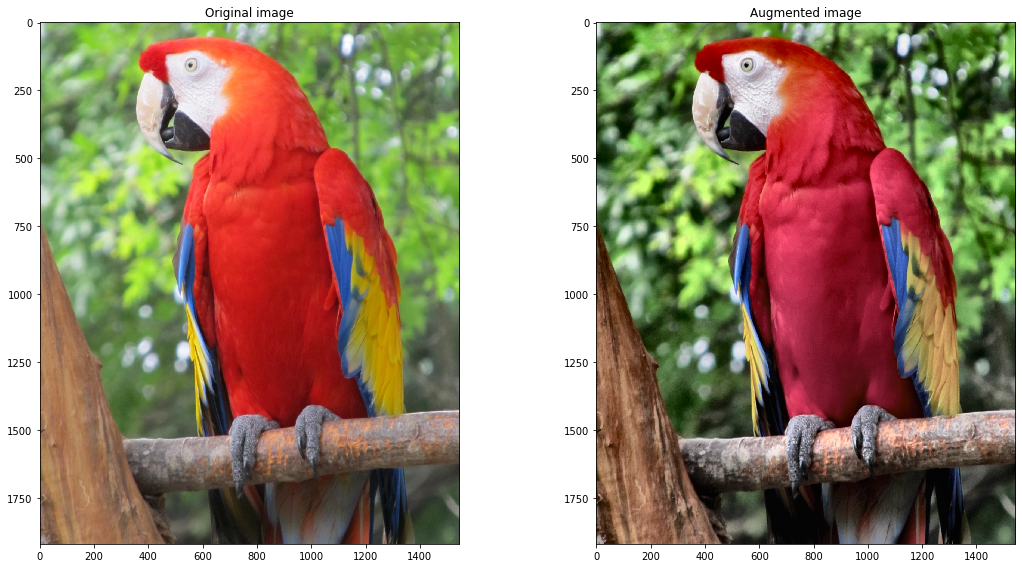

### 2.1.2 Use Cross Validation Kfold

![](https://user-images.githubusercontent.com/26833433/258589390-8d815058-ece8-48b9-a94e-0e1ab53ea0f6.png)

### 2.1.3 Use all model to predict and vote

![](https://miro.medium.com/v2/resize:fit:1100/format:webp/0*Lp5aIdSuk4uqGNwO.png)

# Train and predict EVA02

In [ ]:
!nvidia-smi

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import timm
from fastai.vision.all import *
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
import gc

In [ ]:
def random_seed(seed_value, use_cuda):
    np.random.seed(seed_value)
 #cpu vars
    torch.manual_seed(seed_value)
# cpu  vars
    random.seed(seed_value)
 # Python
    if use_cuda:
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
# gpu vars
        torch.backends.cudnn.deterministic = True
 #needed
        torch.backends.cudnn.benchmark = False
#Remember to use num_workers=0 when creating the DataBunch.
torch.cuda.set_device('cuda:0')
random_seed(3407,True)

In [ ]:
!unzip -qq /content/drive/MyDrive/UBW/train.zip -d /content/datasets

In [ ]:
!unzip -qq /content/drive/MyDrive/UBW/test.zip -d /content/test

In [ ]:
train_df = pd.read_csv('/content/datasets/train.csv')
train_df['id'] = train_df['id'].apply(lambda x : "/content/datasets/train/" + x)
train_df

In [ ]:
strat_kfold = MultilabelStratifiedKFold(n_splits=10, random_state=42, shuffle=True)
train_df['fold'] = -1
for i, (_, test_index) in enumerate(strat_kfold.split(train_df.id.values, train_df.iloc[:,1:].values)):
    train_df.iloc[test_index, -1] = i
train_df.head()

In [ ]:
class AlbumentationsTransform (RandTransform):
    split_idx,order=None,2
    def __init__(self, train_aug, valid_aug): store_attr()

    def before_call(self, b, split_idx):
        self.idx = split_idx

    def encodes(self, img: PILImage):
        if self.idx == 0:
            aug_img = self.train_aug(image=np.array(img))['image']
        else:
            aug_img = self.valid_aug(image=np.array(img))['image']
        return PILImage.create(aug_img)

In [ ]:
import albumentations
from albumentations.pytorch import ToTensorV2
warnings.filterwarnings('ignore')
size = 448
def get_train_aug(): return albumentations.Compose([
            albumentations.Resize(always_apply=False, p=1.0, height=size, width=size, interpolation=0),
            # AutoContrast(),
            # albumentations.PadIfNeeded(always_apply=False, p=1.0, min_height=size, min_width=size, pad_height_divisor=None, pad_width_divisor=None, border_mode=0, value=(255, 255, 255), mask_value=None), #Extra tip, use size that's suitable for the efficentNetwork you are using.
            # albumentations.Rotate(limit=(-20, 20)),
            # albumentations.HorizontalFlip(p=0.5),
            # albumentations.VerticalFlip(p=0.5),
            #albumentations.Sharpen(always_apply=False, p=1.0, alpha=(0.2, 0.5), lightness=(0.5, 1.0)),
            albumentations.GaussianBlur(always_apply=False, p=1.0, blur_limit=(3, 7), sigma_limit=(0.0, 0)),
            # #albumentations.ShiftScaleRotate(always_apply=False, p=1.0, shift_limit_x=(-0.06, 0.06), shift_limit_y=(-0.06, 0.06), scale_limit=(-0.1, 0.1), rotate_limit=(-20, 20), interpolation=0, border_mode=0, value=(255, 255, 255), mask_value=None, rotate_method='largest_box'),
            # albumentations.HueSaturationValue(
            #     hue_shift_limit=0.2,
            #     sat_shift_limit=0.2,
            #     val_shift_limit=0.2,
            #     p=0.5
            # ),
            # albumentations.ColorJitter(contrast=(0.9, 1.1)),
            # #albumentations.CLAHE(always_apply=False, p=0.5, clip_limit=(1, 4), tile_grid_size=(8, 8)),
            albumentations.RandomBrightnessContrast(brightness_limit=(-0.2,0.2), contrast_limit=(-0.2, 0.2), p=0.5 ),
            #albumentations.RandomGamma(),
            #albumentations.ToGray(always_apply=False, p=1.0)

           #albumentations.RandomGridShuffle(p=0.5)\
    ], p=1.)



def get_valid_aug(): return albumentations.Compose([
            albumentations.Resize(always_apply=False, p=1.0, height=size, width=size, interpolation=0),

            #albumentations.PadIfNeeded(always_apply=False, p=1.0, min_height=size, min_width=size, pad_height_divisor=None, pad_width_divisor=None, border_mode=0, value=(255, 255, 255), mask_value=None),
            #albumentations.ToGray(always_apply=False, p=1.0),
            #AutoContrast(),

            ], p=1.0)

item_tfms = AlbumentationsTransform(get_train_aug(), get_valid_aug())
batch_tfms = [Normalize.from_stats(*imagenet_stats)]

In [ ]:
def get_data(fold=0):
    return DataBlock(blocks=(ImageBlock,CategoryBlock),
                       get_x=ColReader(0),
                       get_y=ColReader(1),
                       splitter=IndexSplitter(train_df[train_df.fold == fold].index),
                       item_tfms=item_tfms,
                   batch_tfms=[Normalize.from_stats(*imagenet_stats)]
                      ).dataloaders(train_df, bs=6)

In [ ]:
test_df = pd.read_csv('/content/test/sample_submission.csv')
test_df['id'] = test_df['id'].apply(lambda x : "/content/test/test/" + x + ".jpg")
tstpng = test_df.copy()
tstpng.head()

In [ ]:
# eva02_large_patch14_448.mim_m38m_ft_in22k_in1k
# eva02_base_patch14_448.mim_in22k_ft_in22k_in1k
all_preds = []
#cutmix = CutMix(1.)
mixup = MixUp(1.)
for i in range(10):
    print('Round',i)
    dls = get_data(i)

    learn = cnn_learner(dls, 'eva02_base_patch14_448.mim_in22k_ft_in22k_in1k',metrics=accuracy,cbs= [SaveModelCallback(monitor='valid_loss'),mixup]).to_fp16()
    #learn.fit_one_cycle(10, slice(1e-5,1e-4))
    learn.fine_tune(30)
#     learn.fit_one_cycle(10, cbs=EarlyStoppingCallback(monitor='valid_loss'))
#     learn.dls = get_data(i,512,32)
#     learn.fine_tune(10,cbs=EarlyStoppingCallback(monitor='valid_loss'))


    tst_dl = learn.dls.test_dl(tstpng)
    preds, _ = learn.get_preds(dl=tst_dl)
    all_preds.append(preds)
    del learn
    torch.cuda.empty_cache()
    gc.collect()

In [ ]:
sub = pd.read_csv('/content/test/sample_submission.csv')
preds = np.mean(np.stack(all_preds), axis=0)
preds = torch.from_numpy(preds)

In [ ]:
#tta_preds, _ = tta
idxs = preds.argmax(dim=1)
vocab = np.array(dls.vocab)
sub = pd.read_csv('/content/test/sample_submission.csv')
sub['class'] = vocab[idxs]
sub

In [ ]:
%cd /content/drive/MyDrive/UBW

In [ ]:
sub.to_csv("UWB_EVA02_2.csv",index=False)

## 2.2 image classification (model = yolov8-cls)

### 2.2.1 Only resize to 640x640

# Train and predict Yolov8-cls

In [ ]:
!pip install ultralytics

In [ ]:
## Train ##

from ultralytics import YOLO

# Load a model
model = YOLO('yolov8m-cls.pt')  # load a pretrained model (recommended for training)

# Train the model
results = model.train(data='image_yolo', epochs=100, imgsz=640)

In [ ]:
## Predict ##

from ultralytics import YOLO
import pandas as pd

model_path = 'runs/classify/train/weights/'

Model = 'best.pt'

model = YOLO(model_path + Model)
submission = pd.read_csv('sample_submission.csv')
Ans = []
for i in range(len(submission['id'])):
  name = submission['id'][i] + '.jpg'
  results = model('test/'+name)
  Ans.append(results[0].probs.cpu().data.numpy().argmax())
submission['class'] = Ans


test.to_csv('yolo-cls.csv', index=False)

## 2.3 image detection (model = yolov8,RT-DETR,p6,Ghost convolution)

### 2.3.1 Use Cross Validation Kfold
### 2.3.2 Auto-augment (hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, degrees=0.0, translate=0.1, scale=0.5, shear=0.0, perspective=0.0, flipud=0.0, fliplr=0.5, mosaic=1.0, mixup=0.0, copy_paste=0.0)
### 2.3.3 Labels is hold image. (clss 0.5 0.5 1 1)
### 2.3.4 Use that most confidence bounding boxes to answer that classes

# Create label, create kfold data,train single model, train kfold, predicta and predict all kfold model for yolov8,RT-DETR,p6,Ghost convolution

In [ ]:
!pip install ultralytics

In [ ]:
## Generate labels ##

os.mkdir('/kaggle/working/labels')
for i in range(len(df_annotations)):
    Classes = df_annotations['class'][i]
    text = str(Classes) + " 0.5 0.5 1 1"
    name = str(i)+ ".txt"
    file = open('/kaggle/working/labels/' + name,'w')
    file.write(text)
    file.close()

In [ ]:
## create kfold for yolov8 ##

import datetime
import shutil
from pathlib import Path
from collections import Counter

import yaml
import numpy as np
import pandas as pd
from ultralytics import YOLO
from sklearn.model_selection import KFold


dataset_path = Path('./train') # replace with 'path/to/dataset' for your custom data
labels = sorted(dataset_path.rglob("*labels/*.txt")) # all data in 'labels'


yaml_file = 'data.yaml'  # your data YAML with data directories and names dictionary
with open(yaml_file, 'r', encoding="utf8") as y:
    classes = yaml.safe_load(y)['names']
cls_idx = sorted(classes.keys())


indx = [l.stem for l in labels] # uses base filename as ID (no extension)
labels_df = pd.DataFrame([], columns=cls_idx, index=indx)


for label in labels:
    lbl_counter = Counter()

    with open(label,'r') as lf:
        lines = lf.readlines()

    for l in lines:
        # classes for YOLO label uses integer at first position of each line
        lbl_counter[int(l.split(' ')[0])] += 1

    labels_df.loc[label.stem] = lbl_counter

labels_df = labels_df.fillna(0.0) # replace `nan` values with `0.0`

ksplit = 5
kf = KFold(n_splits=ksplit, shuffle=True, random_state=20)   # setting random_state for repeatable results

kfolds = list(kf.split(labels_df))

folds = [f'split_{n}' for n in range(1, ksplit + 1)]
folds_df = pd.DataFrame(index=indx, columns=folds)

for idx, (train, val) in enumerate(kfolds, start=1):
    folds_df[f'split_{idx}'].loc[labels_df.iloc[train].index] = 'train'
    folds_df[f'split_{idx}'].loc[labels_df.iloc[val].index] = 'val'
    
fold_lbl_distrb = pd.DataFrame(index=folds, columns=cls_idx)

for n, (train_indices, val_indices) in enumerate(kfolds, start=1):
    train_totals = labels_df.iloc[train_indices].sum()
    val_totals = labels_df.iloc[val_indices].sum()

    # To avoid division by zero, we add a small value (1E-7) to the denominator
    ratio = val_totals / (train_totals + 1E-7)
    fold_lbl_distrb.loc[f'split_{n}'] = ratio
    
supported_extensions = ['.jpg', '.jpeg', '.png']

# Initialize an empty list to store image file paths
images = []

# Loop through supported extensions and gather image files
for ext in supported_extensions:
    images.extend(sorted((dataset_path / 'images').rglob(f"*{ext}")))

# Create the necessary directories and dataset YAML files (unchanged)
save_path = Path(dataset_path / f'{datetime.date.today().isoformat()}_{ksplit}-Fold_Cross-val')
save_path.mkdir(parents=True, exist_ok=True)
ds_yamls = []

for split in folds_df.columns:
    # Create directories
    split_dir = save_path / split
    split_dir.mkdir(parents=True, exist_ok=True)
    (split_dir / 'train' / 'images').mkdir(parents=True, exist_ok=True)
    (split_dir / 'train' / 'labels').mkdir(parents=True, exist_ok=True)
    (split_dir / 'val' / 'images').mkdir(parents=True, exist_ok=True)
    (split_dir / 'val' / 'labels').mkdir(parents=True, exist_ok=True)

    # Create dataset YAML files
    dataset_yaml = split_dir / f'{split}_dataset.yaml'
    ds_yamls.append(dataset_yaml)

    with open(dataset_yaml, 'w') as ds_y:
        yaml.safe_dump({
            'path': split_dir.as_posix(),
            'train': 'train',
            'val': 'val',
            'names': classes
        }, ds_y)
        
for image, label in zip(images, labels):
    for split, k_split in folds_df.loc[image.stem].items():
        # Destination directory
        img_to_path = save_path / split / k_split / 'images'
        lbl_to_path = save_path / split / k_split / 'labels'

        # Copy image and label files to new directory (SamefileError if file already exists)
        shutil.copy(image, img_to_path / image.name)
        shutil.copy(label, lbl_to_path / label.name)
        
folds_df.to_csv(save_path / "kfold_datasplit.csv")
fold_lbl_distrb.to_csv(save_path / "kfold_label_distribution.csv")

In [ ]:
## YOLOv8 ##

from ultralytics import YOLO

# Load a model
model = YOLO('yolov8x.pt')  # load a pretrained model (recommended for training)


# Train the model
results = model.train(data='data.yaml', epochs=100, imgsz=640)

In [ ]:
## RT-DETR ##

from ultralytics import RTDETR

# Load a COCO-pretrained RT-DETR-l model
model = RTDETR('rtdetr-l.pt')


# Train the model
results = model.train(data='data.yaml', epochs=100, imgsz=640)

In [ ]:
## YOLOv8 p6 ##

from ultralytics import YOLO

# Load a model
model = YOLO('yolov8x-p6.yaml')  # load a pretrained model (recommended for training)

# Train the model
results = model.train(data='data.yaml', epochs=100, imgsz=640)

In [ ]:
## ghost convolution ##

from ultralytics import YOLO

# Load a model
model = YOLO('yolov8x-ghost.yaml')  # load a pretrained model (recommended for training)

# Train the model
results = model.train(data='data.yaml', epochs=100, imgsz=640)

In [ ]:
## YOLOv8 + kfold ##

ksplit = 5


# Define your additional arguments here
batch = -1
project = ['kfold-1','kfold-2','kfold-3','kfold-4','kfold-5']
epochs = 100

for k in range(ksplit):
    model = YOLO('yolov8n.pt')
    dataset_yaml = ds_yamls[k]
    model.train(data=dataset_yaml,epochs=epochs, batch=batch, project=project[k])  # include any train arguments

In [ ]:
## Predict ##

from ultralytics import YOLO
import pandas as pd

# Load a pretrained YOLOv8n model
model = YOLO('runs/detect/yolov8x/weights/best.pt')

test = pd.read_csv('sample_submission.csv')

CLS = []
CONF = []

for image in test['id']:

    # Define path to the image file
    source = 'test/' + image + '.jpg'

    # Run inference on the source
    results = model(source)

    Conf = []
    Cls = []

    for result in results:
        if len(result.boxes.conf) > 1:
            conf = float(result.boxes.conf[0])
            cls = int(result.boxes.cls[0])
        else:
            conf = 0
            cls = 0
        Conf.append(conf)
        Cls.append(cls)

    max_index = Conf.index(max(Conf))
    final_class = Cls[max_index]
    final_conf = Conf[max_index]

    CLS.append(final_class)
    CONF.append(final_conf)

test['class'] = CLS
test['conf'] = CONF


test.to_csv('yolov8x.csv', index=False)

## Note: Image classification will use prob to defind class but detection will use confidence to defind class and I want the model to be difference to use it to ensemble.
## Note: If all model that we use for ensemble is similar to each other, it will not improve the result. That why I try to use difference methor to generate submission file.

# 3. Ensemble

After using difference parameter to generate submission file. For instance, 

EVA02
- Absolute (transpose):10 kfold, Fine-tuning 20 epoches
- DC Noise cancellation:10 kfold, Fine-tuning 30 epoches
- DC Noise cancellation:5 kfold, Fine-tuning 40 epoches

YOLO-cls
- train-test-split

YOLOv8
- Use difference size of model(m,l,x)
- P6
- Ghost convolution


In [27]:
# Ensemble code

df_path = '/kaggle/input/submission-uwb/'
DF = os.listdir(df_path)

test = pd.read_csv('/kaggle/input/ultra-wide-band-pose-prediction/sample_submission.csv')

ANS = []


for i in range(len(test)):
    

    CONF = [0,0,0,0,0,0,0]


    for df in DF:
        df_sub = pd.read_csv(df_path+df)
        CONF[int(df_sub['class'][i])] = CONF[int(df_sub['class'][i])] + 1

    max_index = CONF.index(max(CONF))
    ANS.append(max_index)

test['class'] = ANS


test.to_csv('submission.csv', index=False)

# To improve evenmore
## 1. Use ensemble submission to be base file for other combination of ensembling
## 2. Use pseudo labeling to generate more train images for train
## 3. Use Test-Time Augmentation (TTA) to predict